Imports

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from adjustText import adjust_text
from matplotlib.lines import Line2D
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

Constants and Global variables

In [2]:
# Constants
EXPRESSION_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Motor_cortex\\Expression_TE_DESeq_Motor_cortex.csv"
DEA_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Goglioti2018_Motor_cortex\\DEA_TE_DESeq_Motor_cortex.csv"
CLINICAL_DATA = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\Clinical_Data_Gogliotti18.csv"
INTERGENIC_FILE = "C:\\Users\\Ana\\Documents\\Estágio\\Goglioti2018\\TE_Intergenic_With_Distances_Motor_cortex.bed"

# Variables
expression_df = None
dea_df = None
genes_of_interest = None

Expression - Import

In [3]:
expression_df = pd.read_csv(EXPRESSION_FILE)
expression_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
expression_df.head()

,TE,mCTX_Ctrl_1,mCTX_Ctrl_2,mCTX_Ctrl_3,mCTX_Ctrl_4,mCTX_Ctrl_5,mCTX_Ctrl_6,mCTX_Ctrl_7,mCTX_Ctrl_8,mCTX_RTT_1,mCTX_RTT_3,mCTX_RTT_4,mCTX_RTT_5,mCTX_RTT_6,mCTX_RTT_7
0,TE_MER1A_dup1,2,0,0,4,5,0,0,24,2,0,0,0,0,0
1,TE_AluJr_dup7,0,19,0,11,2,0,1,8,0,0,16,1,0,0
2,TE_L2a_dup16,144,69,138,133,76,141,16,32,157,75,113,78,70,30
3,TE_L2a_dup18,3,7,3,2,0,0,0,0,3,0,5,2,1,0
4,TE_L1MC3_dup2,4,0,0,0,0,3,0,0,5,0,1,0,15,0


DEA - Import

In [4]:
dea_df = pd.read_csv(DEA_FILE)
dea_df.rename(columns = {'Unnamed: 0' : 'TE'}, inplace = True)
dea_df.dropna(subset =['padj'], inplace = True)
dea_df.head()

,TE,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
0,TE_MLT1F_dup2985,41.878561,-1.950532,0.322449,-6.049113,1.456450e-09,0.000005
1,TE_L2_dup55925,123.756684,-1.068922,0.194633,-5.491980,3.974528e-08,0.000062
2,TE_L2b_dup96098,1264.712965,0.568292,0.108553,5.235184,1.648209e-07,0.000172
3,TE_OldhAT1_dup4104,155.176106,-0.972074,0.196574,-4.945076,7.611411e-07,0.000596
4,TE_L1ME4b_dup2115,14.223422,2.370476,0.540263,4.387631,1.145918e-05,0.007183


Volcano plot

Classification
Non-significant    3026
Down-regulated       62
Up-regulated         46
Name: count, dtype: int64
108
Total tes:
35312
1028
        0          1          2                    TE      4  5             6  \
0    chr1  113691136  113692886     TE_Tigger2_dup139  13590  +  TcMar-Tigger   
1    chr1  219218401  219218614       TE_MER30_dup306   1286  +   hAT-Charlie   
2   chr10   95169125   95169562       TE_L1M5_dup5906    569  +            L1   
3   chr14   50416485   50416861     TE_LTR16E1_dup535   1084  +          ERVL   
4   chr15   23309106   23309417      TE_AluY_dup29818   2115  -           Alu   
5   chr16   31192559   31192871     TE_AluSx_dup39704   2036  -           Alu   
6   chr16   31192968   31193203     TE_AluSp_dup17558   1676  -           Alu   
7   chr16   31193728   31193946     TE_AluJr_dup29373   1125  -           Alu   
8   chr16   31194286   31194603     TE_AluJb_dup45102   1623  -           Alu   
9   chr16   31194611   31194770      TE_L1MA7_dup24

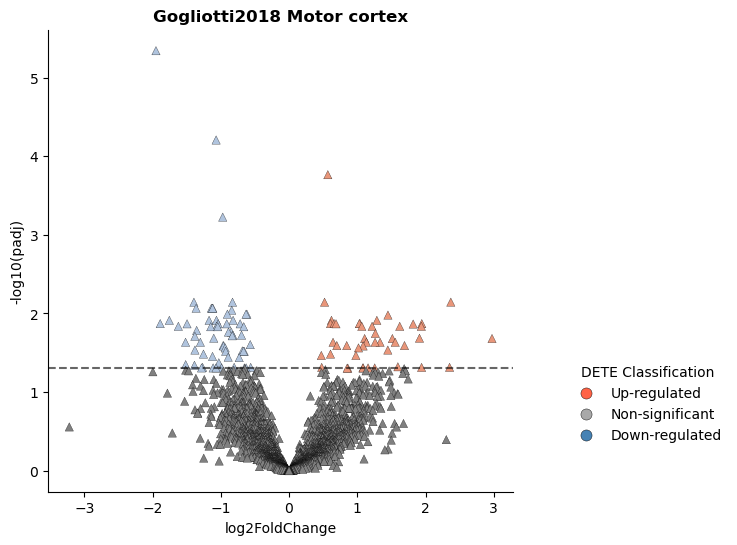

In [5]:

# Organizes the classification, according to the defined values
def organize_classification():
    dea_df['-log10(padj)'] = -np.log10(dea_df['padj'])

    dea_df['Classification'] = dea_df.apply(
        lambda row:
        'Up-regulated' if (row['log2FoldChange'] > 0 and row['padj'] < 0.05)
        else 'Down-regulated' if (row['log2FoldChange'] < -0 and row['padj'] < 0.05)
        else 'Non-significant',
        axis = 1
    )

# Sets the graph's reference lines and labels
def set_lines_and_labels(ax):
    ax.axhline(y = -np.log10(0.05), color = 'black', linestyle = '--', alpha = 0.6)

    ax.set_title('Gogliotti2018 Motor cortex', fontweight = 'bold', fontsize = 12)
    ax.set_xlabel('log2FoldChange')
    ax.set_ylabel('-log10(padj)')

# Gets the genes with the biggest change in expression
def get_genes_of_interest():
    significant_df = dea_df[dea_df['Classification'] != 'Non-significant']
    top_up = significant_df.nlargest(5, 'log2FoldChange')['TE'].tolist()
    top_down = significant_df.nsmallest(5, 'log2FoldChange')['TE'].tolist()
    genes_of_interest = top_up + top_down

    dea_df['Classification'] = np.where(dea_df['TE'].isin(genes_of_interest), 
                                        'GOI_' + dea_df['Classification'],
                                        dea_df['Classification'])
    
    return genes_of_interest

# Sets the genes of interest's names on the graph
def set_genes_of_interest_legend(ax):
    global genes_of_interest
    genes_of_interest = get_genes_of_interest()
    texts = []
    for i, row in dea_df.iterrows():
        if row['TE'] in genes_of_interest:
            texts.append(ax.text(row['log2FoldChange'], row['-log10(padj)'], row['TE'],
                         fontsize = 7, color = 'black', fontweight = 'semibold'))
            
    adjust_text(texts, expand_points = (1.5, 1.5), arrowprops = dict(arrowstyle = '-', color = 'black', lw = 0.8), save_steps = False)
    print(texts)

# Sets the main chart legend on the plot
def set_plot_legends(ax):
    #set_genes_of_interest_legend(ax)
    legend_elements = [Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'tomato',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3, 
                            label = 'Up-regulated'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'darkgray',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Non-significant'),
                    Line2D([0], [0], marker = 'o', color = 'w', markerfacecolor = 'steelblue',
                            markeredgecolor = 'k', markersize = 8, markeredgewidth = 0.3,
                            label = 'Down-regulated')]
    ax.legend(handles = legend_elements, title = 'DETE Classification', bbox_to_anchor = (1.1, 0.3), frameon = False)

# Main function, gets the volcano plot
def get_volcano_plot():
    organize_classification() # Organiza-se primeiro a tabela com a classificação
    print(dea_df['Classification'].value_counts())
    subset = dea_df[dea_df['Classification'] != 'Non-significant']
    print(len(subset))
    print('Total tes:')
    print(len(expression_df))
    
    intergenic_df = pd.read_csv(INTERGENIC_FILE, sep = '\t', header = None, comment = '#')
    intergenic_df = intergenic_df[intergenic_df.iloc[:, -1] > 4000]
    print(intergenic_df.shape[0])

    intergenic_df = intergenic_df.rename(columns = {intergenic_df.columns[3] : 'TE'})
    intergenic_dete_df = intergenic_df.merge(dea_df, on = 'TE', how = 'inner')
    print(intergenic_dete_df)
    intergenic_dete_df = intergenic_dete_df[intergenic_dete_df['Classification'] != 'Non-significant']
    print('intergenic dete')
    print(intergenic_dete_df.shape[0])

    fig, ax = plt.subplots(figsize = (6, 6)) # Criamos o gráfico
    
    palette_dea = {'GOI_Up-regulated' : 'tomato',
                   'GOI_Down-regulated' : 'steelblue',
                   'Up-regulated' : 'darksalmon',
                   'Down-regulated' : 'lightsteelblue',
                   'Non-significant' : 'gray'}
    
    sns.scatterplot(data = dea_df,  
                    x = 'log2FoldChange', 
                    y = '-log10(padj)',
                    palette = palette_dea, 
                    hue = 'Classification', 
                    edgecolor = 'black',
                    linewidth = 0.2, 
                    legend = False,
                    marker = '^')
    
    set_lines_and_labels(ax) # Colocamos as labels que queremos
    set_plot_legends(ax) # Colocamos as legendas por último
    sns.despine()
    plt.show()
    
get_volcano_plot()



PCA - Data frame

In [6]:
# Variables
TEs = expression_df.iloc[:, 0]
counts = expression_df.iloc[:, 1:]
clinical_data = pd.read_csv(CLINICAL_DATA)
clinical_data = clinical_data[clinical_data['Brain_Region'] == 'Motor Cortex']
clinical_data = clinical_data[clinical_data['MECP2_Mutation'].isin(['R270X', 'R255X', 'None (WT)'])]

print(expression_df)
# Process counts
library_size = counts.sum(axis = 0)
cpm_df = counts.div(library_size, axis = 1) * 1e6
log2cpm_df = np.log2(cpm_df + 1)
print(log2cpm_df.head())

filtered_samples = clinical_data['Sample_Name'].tolist()
print(clinical_data[['Sample_Name', 'Sample_ID']])
log2cpm_df = log2cpm_df[filtered_samples]

# Process clinical data
clinical_data = clinical_data[['Sample_Name', 'Condition', 'Sample_ID', 'MECP2_Mutation']]

# Scaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(log2cpm_df.T)

pca = PCA(n_components = 2)
pca_res = pca.fit_transform(scaled_data)

# PCA data frame
pca_df = pd.DataFrame(pca_res, index = log2cpm_df.columns, columns = [f"PC{i+1}" for i in range(2)])
pca_df.reset_index(names = 'Sample_Name', inplace = True)
pca_df = pca_df.merge(clinical_data, on = 'Sample_Name', how = 'inner')


pca_df

                      TE  mCTX_Ctrl_1  mCTX_Ctrl_2  mCTX_Ctrl_3  mCTX_Ctrl_4  \
0          TE_MER1A_dup1            2            0            0            4   
1          TE_AluJr_dup7            0           19            0           11   
2           TE_L2a_dup16          144           69          138          133   
3           TE_L2a_dup18            3            7            3            2   
4          TE_L1MC3_dup2            4            0            0            0   
...                  ...          ...          ...          ...          ...   
35307  TE_THE1B_dup22662            1            0            3            0   
35308  TE_L1PA3_dup10870            0            0            0            0   
35309    TE_L1HS_dup1649            0            0            0            0   
35310  TE_L1PA15_dup8434            0            0            0            0   
35311     TE_L3_dup45883            0            7            0            0   

       mCTX_Ctrl_5  mCTX_Ctrl_6  mCTX_C

,Sample_Name,PC1,PC2,Condition,Sample_ID,MECP2_Mutation
0,mCTX_Ctrl_1,52.823664,-18.585181,Ctrl,3325-CMN-1,None (WT)
1,mCTX_Ctrl_2,97.567310,-28.297501,Ctrl,3325-CMN-2,None (WT)
2,mCTX_Ctrl_3,-40.915444,-34.983590,Ctrl,3325-CMN-3,None (WT)
3,mCTX_Ctrl_4,54.714954,-31.669157,Ctrl,3325-CMN-4,None (WT)
4,mCTX_Ctrl_5,25.794979,-15.823376,Ctrl,3325-CMN-5,None (WT)
5,mCTX_Ctrl_6,42.988493,-28.068522,Ctrl,3325-CMN-6,None (WT)
6,mCTX_Ctrl_7,70.679466,-19.058779,Ctrl,3325-CMN-7,None (WT)
7,mCTX_Ctrl_8,-44.377574,-12.001537,Ctrl,3325-CMN-8,None (WT)
8,mCTX_RTT_1,-81.262326,-9.800794,RTT,3325-CMN-9,R255X
9,mCTX_RTT_3,34.234971,200.874414,RTT,3325-CMN-11,R255X


PCA - Graph

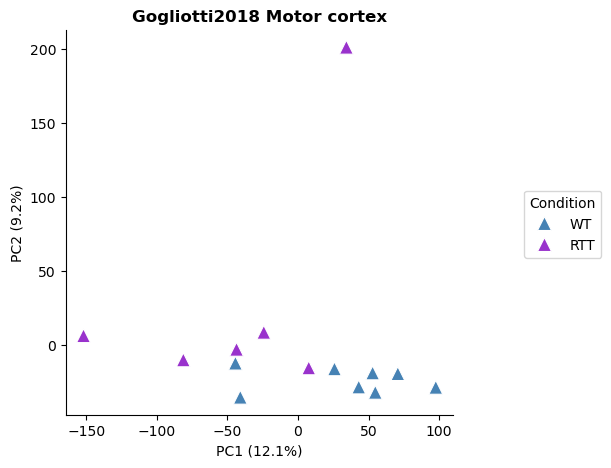

In [7]:
fig, ax = plt.subplots(figsize = (5, 5))
palette_pca = {'WT' : 'steelblue',
               'RTT' : 'darkorchid'}

pca_df['Condition'] = pca_df['Condition'].replace({'Ctrl' : "WT"})
sns.scatterplot(data = pca_df, x = 'PC1', y = 'PC2', palette = palette_pca, hue = 'Condition', s = 100, marker = '^')
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)") # f-string é uma forma moderna de formatar strings em python, valor da variância * 100 para meter em percentagem e dps coloca só com uma casa decimal
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("Gogliotti2018 Motor cortex", fontweight = 'bold', fontsize = 12)
ax.legend(title = 'Condition', bbox_to_anchor = (1.4, 0.6))
sns.despine()
plt.show()


Boxplot

In [8]:
# Assemble the new table
log2cpm_df.insert(0, 'TE', TEs)
goi_df = log2cpm_df[log2cpm_df['TE'].isin(genes_of_interest)]

long_df = goi_df.melt(id_vars = 'TE', var_name = 'Sample_Name', value_name = 'log2(CPM)')
long_df = long_df.merge(clinical_data, on = 'Sample_Name', how = 'left')

print(clinical_data.head())

# Assemble the plot

fig, ax = plt.subplots(figsize = (12, 12))

palette_boxplot = {'RTT' : 'tomato',
                   'Ctrl' : 'steelblue'}

sns.boxplot(data = long_df, x = 'TE', y = 'log2(CPM)', hue = 'Condition', palette = palette_boxplot,
                fliersize = 2, linewidth = 2)

ax.set_title('Boxplot - TEs - Motor cortex', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('TEs')
ax.set_ylabel('log2(CPM)')
ax.tick_params(axis = 'x', rotation = 45)



TypeError: only list-like objects are allowed to be passed to isin(), you passed a `NoneType`